# Treino: um dicionário por experimento

Cada treino do projeto é um dicionário com três partes:

```python
{"modelo": "frr" | "mindeye2" | "mindeye1",
 "hiper":   {...},     # hiperparâmetros do modelo; o que faltar fica no padrão
 "dataset": {...}}     # o dataset controlado; vazio = o dataset completo (40 sessões)
```

`roda(nome, experimento)`, do `src/treina.py`, sorteia o dataset (um manifesto em
`train_logs/<nome>/dataset.json`), registra a configuração inteira com o commit do código
(`experimento.json`) e chama o script de treino do modelo:

| Modelo | Script | O que treina | Onde fica |
|---|---|---|---|
| `frr` | `scripts/run_frr.sh` | regressão ridge fracionária, voxels → embedding CLIP; já avalia o retrieval | `results/tables/<nome>_frr.json` |
| `mindeye2` | `scripts/run_ridgeonly_prior.sh` | só a ridge do subj01, a partir do pré-treino nos outros 7 sujeitos | `train_logs/<nome>/` |
| `mindeye1` | `scripts/me1_run.sh train` | o MindEye1 do zero (alto nível) | `mindeye1/train_logs/<nome>/` |

Os dicionários ficam em `src/experimentos.py`: `BENCHMARK` (os modelos já treinados, seção 1) e
`EXPERIMENTOS` (os novos). O mesmo dá para fazer pela linha de comando:
`python src/treina.py --lista`, `python src/treina.py <nome> [--dry_run]`.

As células que treinam de verdade só rodam com `TREINAR = True`. Com `False`, o notebook inteiro
roda em segundos e só mostra o que seria feito.

## 0. Configuração

In [1]:
%matplotlib inline
import io
import sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image as IPImage, display

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "treina.py").exists())
sys.path.insert(0, str(REPO / "src"))
from experimentos import BENCHMARK, CLASSES_5, EXPERIMENTOS
from mindeye_ridge import dataset_controlado as dc
from mindeye_ridge import resultados
from mindeye_ridge.paths import DATA, TRAIN_LOGS
from treina import MODELOS, roda

TREINAR = False     # True roda as celulas de treino: minutos no FRR, horas no MindEye

plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
pct = lambda v: "—" if v is None or pd.isna(v) else f"{100 * v:.1f}%"
print("python:", sys.executable, "| dados:", DATA)

python: /home/al.pedro.alberti/envs/fmri/bin/python | dados: /home/al.pedro.alberti/mindeyev2


## 1. Os modelos já treinados

Os modelos do benchmark (`BENCHMARK.md`), escritos como dicionários. Cada um reproduz o treino que
gerou o modelo: o mesmo script, os mesmos hiperparâmetros e o dataset completo das N primeiras
sessões. O dicionário de `hiper` vazio quer dizer os padrões do script.

O retrieval vem de onde cada modelo grava (`mindeye_ridge.resultados`), e a coluna `fonte` diz de
onde: o FRR e o `verify_retrieval` sorteiam 30 vezes 300 imagens do teste; o `final_evaluations`
usa as 1.000 imagens em blocos de 300. Img→cér é cada imagem procurando o seu cérebro; cér→img, o
contrário (a convenção do código do MindEye2; ver o `BENCHMARK.md`).

In [2]:
linhas = []
for nome, exp in BENCHMARK.items():
    r = resultados.retrieval(nome) or {}
    linhas.append({"nome": nome, "modelo": exp["modelo"], "sessões": exp["dataset"]["sessoes"],
                   "hiper (fora do padrão)": exp["hiper"] or "—",
                   "img→cér": pct(r.get("fwd")), "cér→img": pct(r.get("bwd")), "fonte": r.get("fonte", "sem resultado")})
pd.set_option("display.max_colwidth", 80)
pd.DataFrame(linhas).set_index("nome")

,modelo,sessões,hiper (fora do padrão),img→cér,cér→img,fonte
nome,,,,,,
subj01_frr_1sess,frr,1,—,55.0%,3.1%,FRR: 30 sorteios de 300 imagens do teste
subj01_frr_40sess,frr,40,—,96.4%,37.7%,FRR: 30 sorteios de 300 imagens do teste
subj01_frr_1sess_global,frr,1,{'global_fraction': True},33.2%,1.3%,FRR: 30 sorteios de 300 imagens do teste
subj01_frr_40sess_global,frr,40,{'global_fraction': True},96.3%,37.7%,FRR: 30 sorteios de 300 imagens do teste
subj01_frr_1sess_ext,frr,1,{'grid': 'extended'},55.7%,2.0%,FRR: 30 sorteios de 300 imagens do teste
subj01_frr_40sess_ext,frr,40,{'grid': 'extended'},92.4%,21.3%,FRR: 30 sorteios de 300 imagens do teste
subj01_ridgeonly_1sess_prior,mindeye2,1,—,92.8%,88.1%,"final_evaluations.py: as 1.000 imagens do teste, em blocos de 300"
subj01_ridgeonly_1sess,mindeye2,1,{'prior': False},78.5%,72.1%,"final_evaluations.py: as 1.000 imagens do teste, em blocos de 300"
subj01_ridgeonly_1sess_4096blurry,mindeye2,1,"{'hidden_dim': 4096, 'blurry': True, 'ckpt_interval': 10}",95.5%,92.0%,"final_evaluations.py: as 1.000 imagens do teste, em blocos de 300"


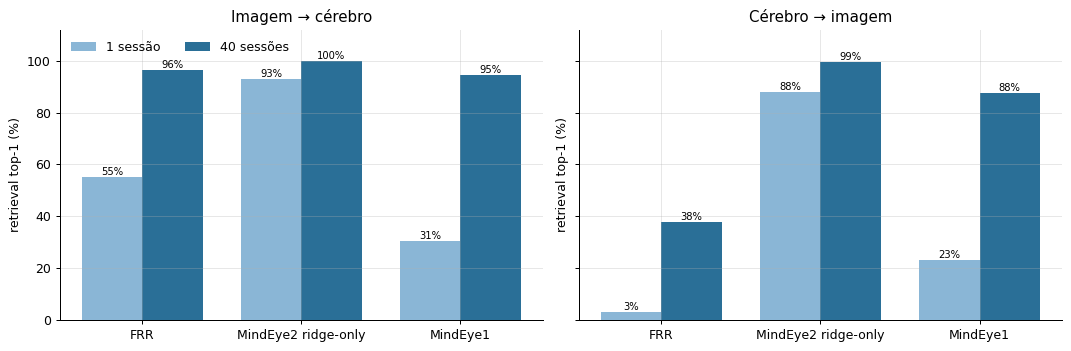

In [3]:
# os principais, lado a lado: 1 e 40 sessoes de cada modelo
principais = {"FRR": ("subj01_frr_1sess", "subj01_frr_40sess"),
              "MindEye2 ridge-only": ("subj01_ridgeonly_1sess_prior", "subj01_ridgeonly_40sess_prior"),
              "MindEye1": ("subj01_me1_1sess", "subj01_me1_40sess")}
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, chave, titulo in zip(axes, ("fwd", "bwd"), ("Imagem → cérebro", "Cérebro → imagem")):
    x = np.arange(len(principais))
    for k, (rotulo, cor) in enumerate((("1 sessão", "#8AB6D6"), ("40 sessões", "#2A6F97"))):
        vals = [(resultados.retrieval(par[k]) or {}).get(chave, np.nan) for par in principais.values()]
        barras = ax.bar(x + (k - 0.5) * 0.38, [100 * v for v in vals], 0.38, color=cor, label=rotulo)
        ax.bar_label(barras, fmt="%.0f%%", fontsize=8)
    ax.set_xticks(x, principais.keys())
    ax.set(title=titulo, ylabel="retrieval top-1 (%)", ylim=(0, 112))
axes[0].legend(loc="upper left", ncols=2, frameon=False)
plt.tight_layout(); plt.show()

As curvas de treino do MindEye2 ficam em `train_logs/<nome>/metrics.csv`, fora do git. Se
existirem nesta máquina, aparecem abaixo: o retrieval no teste a cada época.

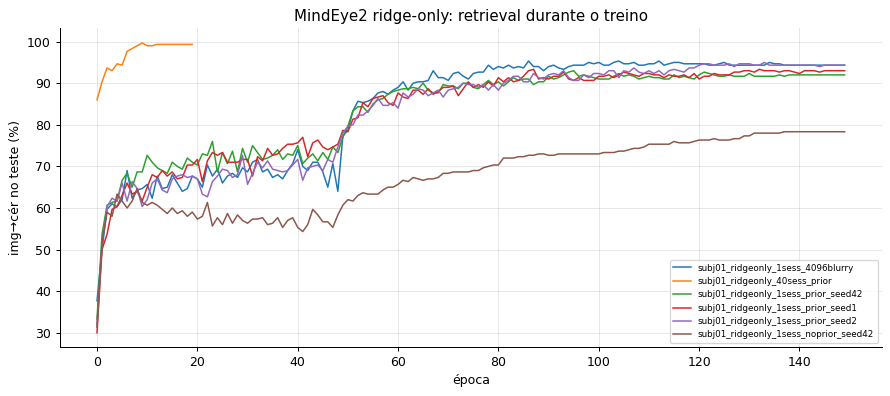

In [4]:
curvas = {n: pd.read_csv(TRAIN_LOGS / n / "metrics.csv") for n, e in BENCHMARK.items()
          if e["modelo"] == "mindeye2" and (TRAIN_LOGS / n / "metrics.csv").exists()}
if not curvas:
    print("nenhum metrics.csv do MindEye2 nesta maquina")
else:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    for n, c in curvas.items():
        ax.plot(c["epoch"], 100 * c["test/test_fwd_pct_correct"], label=n, lw=1.2)
    ax.set(xlabel="época", ylabel="img→cér no teste (%)", title="MindEye2 ridge-only: retrieval durante o treino")
    ax.legend(fontsize=7)
    plt.tight_layout(); plt.show()

## 2. Como o dicionário vira o treino

Com `dry_run=True`, `roda` sorteia o dataset, mostra o resumo e o comando que rodaria, sem gravar
nada. Para o ridge-only de 40 sessões, o comando tem as mesmas variáveis com que o
`scripts/run_benchmark.sh` treinou o modelo (`NUM_SESSIONS=40 NUM_EPOCHS=20 CKPT_INTERVAL=1
FROZEN=1`; as outras são os padrões do script, escritos por extenso). O dataset é o completo: as
27.000 exibições de treino das 40 sessões, 3 por imagem.

In [5]:
BENCHMARK["subj01_ridgeonly_40sess_prior"]

{'modelo': 'mindeye2',
 'hiper': {'num_epochs': 20, 'frozen_fp16': True, 'ckpt_interval': 1},
 'dataset': {'sessoes': 40}}

In [6]:
roda("subj01_ridgeonly_40sess_prior", BENCHMARK["subj01_ridgeonly_40sess_prior"], dry_run=True);

[subj01_ridgeonly_40sess_prior] dataset 63d8dad3: {"exibicoes": 27000, "imagens_unicas": 9000, "repeticoes": {"3": 9000}, "sessoes_usadas": 40}
[subj01_ridgeonly_40sess_prior] HIDDEN_DIM=1024 NUM_EPOCHS=20 MAX_LR=0.0003 PRIOR=1 BLURRY=0 SEED=42 CKPT_INTERVAL=1 FROZEN=1 MODEL_NAME=subj01_ridgeonly_40sess_prior NUM_SESSIONS=40 DATASET=/home/al.pedro.alberti/benchmark-modelos/train_logs/subj01_ridgeonly_40sess_prior/dataset.json bash /home/al.pedro.alberti/benchmark-modelos/scripts/run_ridgeonly_prior.sh


Os hiperparâmetros que cada modelo aceita, com os padrões. Uma chave fora da lista é erro, não é
ignorada:

In [7]:
pd.DataFrame({m: pd.Series(MODELOS[m].padrao) for m in MODELOS}).fillna("").astype(str).replace("None", "(o do script)")

,frr,mindeye2,mindeye1
batch_size,,,
blurry,,False,
chunk,8192,,
ckpt_interval,,,
folds,5,,
fracs,,,
frozen_fp16,,,
global_fraction,False,,
grid,doerig,,
hidden_dim,,1024,


Um nome que já tem modelo treinado não é treinado de novo: `roda` recusa, para nunca sobrescrever
um modelo do benchmark. Para reproduzir um deles, rode o mesmo dicionário com outro nome. O FRR de
1 sessão leva cerca de 1 minuto, e o resultado sai igual ao do benchmark (foi conferido: retrieval,
métricas de embedding e hubness idênticos).

In [8]:
try:
    roda("subj01_frr_1sess", BENCHMARK["subj01_frr_1sess"])
except SystemExit as e:
    print("recusado:", e)

if TREINAR:
    roda("repro_subj01_frr_1sess", BENCHMARK["subj01_frr_1sess"])
    print("benchmark:", resultados.retrieval("subj01_frr_1sess"))
    print("refeito:  ", resultados.retrieval("repro_subj01_frr_1sess"))

recusado: subj01_frr_1sess ja tem um modelo treinado fora do treina.py (/home/al.pedro.alberti/benchmark-modelos/results/tables/subj01_frr_1sess_frr.json).
Para reproduzir esta configuracao, rode o dicionario com outro nome.


## 3. Um experimento novo

Um subconjunto semântico balanceado: 300 imagens de cada uma das 5 classes (a classe ocupa pelo
menos 10% da tela e as outras menos de 2%; ver `notebooks/classificacao_semantica.ipynb`), as 3
exibições de cada imagem, e o FRR treinando na **média** das repetições em vez dos trials
separados.

In [9]:
exp = {"modelo": "frr",
       "hiper": {"seed": 42},
       "dataset": {"sessoes": 40, "classes": CLASSES_5, "minimo": 10, "maximo_outros": 2,
                   "n_imagens": 300, "balanceado": True, "repeticoes": 3,
                   "agregacao": "media", "semente": 0}}
CLASSES_5

{'pessoa': ['sup_person'],
 'animal': ['sup_animal'],
 'veiculo': ['sup_vehicle'],
 'comida': ['sup_food'],
 'moveis': ['sup_furniture']}

`dc.monta` sorteia o subconjunto sem gravar nada. O mesmo dicionário dá sempre o mesmo sorteio
(a `semente`); o resumo diz quantas exibições e imagens entraram e quantas por classe.

In [10]:
sub = dc.monta(dc.ConfigDataset.de_dict(exp["dataset"]), DATA)
sub["resumo"]

{'exibicoes': 4500,
 'imagens_unicas': 1500,
 'repeticoes': {3: 1500},
 'sessoes_usadas': 40,
 'imagens_por_classe': {'animal': 300,
  'comida': 300,
  'moveis': 300,
  'pessoa': 300,
  'veiculo': 300}}

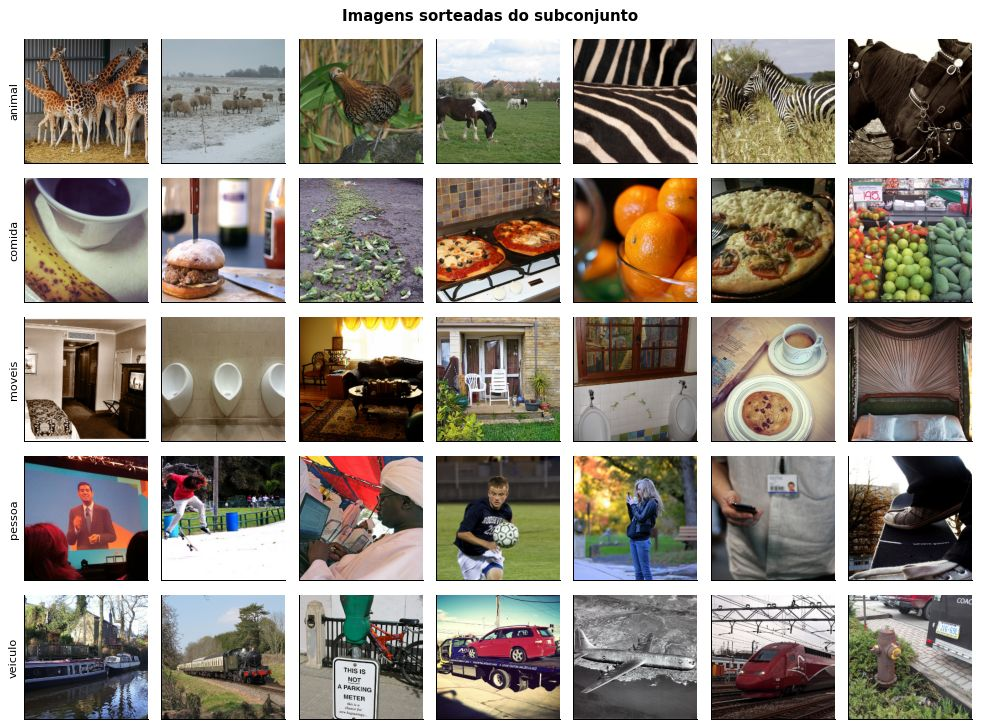

In [11]:
def mostra_jpeg(fig, qualidade=80):
    buf = io.BytesIO()
    fig.savefig(buf, format="jpeg", pil_kwargs={"quality": qualidade}, bbox_inches="tight")
    plt.close(fig)
    display(IPImage(buf.getvalue()))


rng = np.random.default_rng(0)
por_classe = pd.Series(sub["imagem"]).groupby(sub["rotulo"]).unique()
fig, axes = plt.subplots(len(por_classe), 7, figsize=(11, 1.65 * len(por_classe)))
with h5py.File(DATA / "coco_images_224_float16.hdf5", "r") as f:
    for i, (classe, ids) in enumerate(por_classe.items()):
        for j, nid in enumerate(np.sort(rng.choice(ids, 7, replace=False))):
            axes[i, j].imshow(f["images"][nid].astype(np.float32).transpose(1, 2, 0))
            axes[i, j].set_xticks([]); axes[i, j].set_yticks([]); axes[i, j].grid(False)
        axes[i, 0].set_ylabel(classe, fontsize=9)
fig.suptitle("Imagens sorteadas do subconjunto", fontweight="bold")
plt.tight_layout()
mostra_jpeg(fig)

In [12]:
roda("exemplo_frr_5classes_media", exp, dry_run=True)

if TREINAR:
    roda("exemplo_frr_5classes_media", exp)

[exemplo_frr_5classes_media] dataset 1d8fbcde: {"exibicoes": 4500, "imagens_unicas": 1500, "repeticoes": {"3": 1500}, "sessoes_usadas": 40, "imagens_por_classe": {"animal": 300, "comida": 300, "moveis": 300, "pessoa": 300, "veiculo": 300}}
[exemplo_frr_5classes_media] EXTRA='--folds=5 --grid=doerig --seed=42 --chunk=8192' MODEL_NAME=exemplo_frr_5classes_media NUM_SESSIONS=40 DATASET=/home/al.pedro.alberti/benchmark-modelos/train_logs/exemplo_frr_5classes_media/dataset.json bash /home/al.pedro.alberti/benchmark-modelos/scripts/run_frr.sh


Combinações que não fazem sentido param antes de qualquer treino, com a explicação:

In [13]:
for descricao, e in [
    ("FRR com sorteio por época", {**exp, "dataset": {**exp["dataset"], "agregacao": "sorteio"}}),
    ("mais imagens por classe do que existem", {**exp, "dataset": {**exp["dataset"], "n_imagens": 400}}),
    ("hiperparâmetro de outro modelo", {**exp, "hiper": {"num_epochs": 10}}),
    ("MindEye2 com 1 época", {"modelo": "mindeye2", "hiper": {"num_epochs": 1}}),
]:
    try:
        roda("exemplo_invalido", e, dry_run=True)
    except (ValueError, SystemExit) as err:
        print(f"{descricao}:\n    {err}\n")

FRR com sorteio por época:
    frr: agregacao 'sorteio' nao se aplica; use uma de ('exibicoes', 'media')



mais imagens por classe do que existem:
    n_imagens = 400 por classe, mas ha so {'comida': 336} (disponiveis: {'pessoa': 1484, 'animal': 880, 'veiculo': 730, 'comida': 336, 'moveis': 488})

hiperparâmetro de outro modelo:
    hiperparametros desconhecidos: ['num_epochs']; validos: ['chunk', 'folds', 'fracs', 'global_fraction', 'grid', 'seed']

MindEye2 com 1 época:
    mindeye2: num_epochs >= 2 (o OneCycleLR usa pct_start = 2/num_epochs)



## 4. Varreduras

Um experimento por combinação, gerados num laço. Aqui, a pergunta do plano de estágio para um
tempo de aquisição fixo: com as mesmas 3.000 exibições, vale mais ter imagens únicas ou repetições?
E, com 3 repetições, treinar nos trials separados ou na média? A tabela mostra o que cada dataset
contém antes de treinar.

In [14]:
varredura = {}
for n, r in ((3000, 1), (1500, 2), (1000, 3)):
    for agregacao in (("exibicoes", "media") if r > 1 else ("exibicoes",)):
        varredura[f"varre_frr_{n}img_{r}rep_{agregacao}"] = {
            "modelo": "frr", "hiper": {"seed": 42},
            "dataset": {"sessoes": 40, "n_imagens": n, "repeticoes": r, "semente": 0, "agregacao": agregacao}}

linhas = []
for nome, e in varredura.items():
    res = dc.monta(dc.ConfigDataset.de_dict(e["dataset"]), DATA)["resumo"]
    amostras = res["exibicoes"] if e["dataset"]["agregacao"] == "exibicoes" else res["imagens_unicas"]
    linhas.append({"experimento": nome, "imagens": res["imagens_unicas"], "exibições": res["exibicoes"],
                   "agregação": e["dataset"]["agregacao"], "amostras de treino": amostras})
pd.DataFrame(linhas).set_index("experimento")

,imagens,exibições,agregação,amostras de treino
experimento,,,,
varre_frr_3000img_1rep_exibicoes,3000,3000,exibicoes,3000
varre_frr_1500img_2rep_exibicoes,1500,3000,exibicoes,3000
varre_frr_1500img_2rep_media,1500,3000,media,1500
varre_frr_1000img_3rep_exibicoes,1000,3000,exibicoes,3000
varre_frr_1000img_3rep_media,1000,3000,media,1000


In [15]:
if TREINAR:
    for nome, e in varredura.items():     # o que ja terminou e pulado: pode interromper e rodar de novo
        roda(nome, e)

## 5. Resultados

`resultados.retrieval(nome)` serve para qualquer experimento, do benchmark ou novo. O que ainda
não foi treinado aparece sem resultado.

In [16]:
nomes = [*varredura, "exemplo_frr_5classes_media", *EXPERIMENTOS]
tabela = pd.DataFrame([{"experimento": n, **{k: v for k, v in (resultados.retrieval(n) or {}).items()}} for n in nomes])
tabela = tabela.set_index("experimento").reindex(columns=["fwd", "bwd", "fonte"])
tabela.assign(fwd=tabela.fwd.map(pct), bwd=tabela.bwd.map(pct)).fillna({"fonte": "ainda não treinado"})

,fwd,bwd,fonte
experimento,,,
varre_frr_3000img_1rep_exibicoes,—,—,ainda não treinado
varre_frr_1500img_2rep_exibicoes,—,—,ainda não treinado
varre_frr_1500img_2rep_media,—,—,ainda não treinado
varre_frr_1000img_3rep_exibicoes,—,—,ainda não treinado
varre_frr_1000img_3rep_media,—,—,ainda não treinado
exemplo_frr_5classes_media,—,—,ainda não treinado
subj01_frr_5classes_300img_1rep,—,—,ainda não treinado
subj01_me2_pessoa_animal,—,—,ainda não treinado
subj01_me1_1000img_3rep,—,—,ainda não treinado


### Depois do treino

- **FRR:** o `run_frr.py` já avalia; o JSON em `results/tables/<nome>_frr.json` tem retrieval,
  similaridade com o embedding CLIP e o custo.
- **MindEye2:** o `metrics.csv` tem o retrieval no teste a cada época (300 imagens). O retrieval
  final, no protocolo dos outros (30 sorteios de 300), sai do `verify_retrieval.py`:
  `python src/verify_retrieval.py --model_name=<nome> --subj=1 --hidden_dim=1024 --n_blocks=4
  --no-blurry_recon --new_test`. Reconstruções e métricas: `scripts/run_recon.sh <nome> 1024
  noblurry` e `scripts/run_evals.sh <nome> base`.
- **MindEye1:** reconstruções e métricas com as mesmas variáveis do treino, inclusive `DATASET`:
  `MODEL_NAME=<nome> DATASET=train_logs/<nome>/dataset.json NUM_SESSIONS=40 scripts/me1_run.sh
  lowlevel` (e depois `recon` e `metrics`).

Épocas acompanham o tamanho do dataset: com o mesmo `num_epochs`, um subconjunto menor treina menos
passos, e nos modos de agregação por imagem a época tem uma amostra por imagem. Para comparar
condições com o mesmo número de passos, ajuste `num_epochs` (o README explica).